# 3.1 — MobileViT fine-tuning completo — Food-101

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/marcoslund/ViT-for-101-food-app/blob/main/notebooks/3.1-mobilevit.ipynb)

Entrenamiento completo de **MobileViT** (`apple/mobilevit-small`) con la estructura del proyecto y los artefactos de `2.0-preprocessing.ipynb`.

MobileViT es un hibrido **CNN + transformer** pensado para correr **en dispositivo**: bloques convolucionales livianos (estilo MobileNetV2) intercalados con bloques transformer que aplican self-attention sobre parches, a 256px. Es el modelo del regimen *en dispositivo* del benchmark.

- El **codigo de modelo y entrenamiento vive en `modeling/training.py`** y la orquestacion en `modeling/benchmark.py`; aca solo se llaman funciones.
- Reusa `config.py` y `preprocessing/loaders.py`: no se reimplementan resize, crop, normalizacion ni augmentation.
- La evaluacion usa `modeling/evaluation.py`, **el mismo codigo para todos los modelos del benchmark**.
- `test` se usa una sola vez al final; la pregunta del proyecto la contesta el **subset del benchmark por tercil**.
- Al terminar, guarda el mejor modelo y lo **descarga a tu computadora** (sección 8.1).
- Checkpoints bajo `models/mobilevit/full/`; resultados livianos en `reports/results/mobilevit/`.

**Variante:** MobileViT-small (~5M params) es el modelo mas chico del benchmark. Recibe los canales en **BGR** y **no normaliza**: eso lo resuelve `preprocessing` leyendo el `AutoImageProcessor`, no se toca aca. La notebook lee la resolucion del checkpoint y ajusta el batch sola.

> Para una corrida **desatendida** (Kaggle, VM), el mismo pipeline esta como CLI: `python -m vit_for_101_food_app.modeling.train --model mobilevit`.

## 0. Antes de ejecutar

Desde la raiz del repo:

```bash
uv sync --extra deep
uv run jupyter lab
```

El preprocessing debe existir (`make preprocess` o `notebooks/2.0-preprocessing.ipynb`). En **Colab** no hace falta nada previo: sección 0.2 y sección 0.3 arman todo.

## 0.1 Parametros de ejecucion

- `USE_DRIVE` (solo Colab): guarda dataset, checkpoints y resultados en Google Drive. El disco de Colab se borra al desconectarse; sin Drive, una desconexion a mitad de entrenamiento pierde todo.
- `RESUME`: `True` retoma desde el ultimo checkpoint de `OUTPUT_DIR` (corrida cortada). Con `False` y checkpoints viejos, la notebook se detiene en vez de mezclarlos.
- `REPO_BRANCH`: rama que Colab clona. Con todo mergeado a `main`, dejar `"main"`.

In [1]:
# Solo Colab: persistir dataset, checkpoints y resultados en Google Drive.
USE_DRIVE = True
DRIVE_DIR = "/content/drive/MyDrive/ceia-vpc3"

# True = retomar desde el ultimo checkpoint de OUTPUT_DIR (corrida cortada).
RESUME = False

# Rama a clonar en Colab.
REPO_BRANCH = "main"


## 0.2 Entorno (Colab)

En Colab clona el repo (rama `REPO_BRANCH`) e instala el paquete con el extra `deep`. `torch` ya viene con CUDA en Colab. Localmente solo verifica que el paquete este instalado.

In [2]:
import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
print(f"Colab: {IN_COLAB}")


def _paquete_disponible():
    try:
        import vit_for_101_food_app  # noqa: F401

        return True
    except ImportError:
        return False


if IN_COLAB:
    REPO_URL = "https://github.com/marcoslund/ViT-for-101-food-app.git"
    REPO_DIR = "/content/ViT-for-101-food-app"
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "-q", "-b", REPO_BRANCH, REPO_URL, REPO_DIR], check=True)
    else:
        # Ya clonado: traer la ultima version de la rama. Si actualizo codigo del paquete,
        # despues hay que reiniciar el runtime para que se reimporte.
        subprocess.run(["git", "-C", REPO_DIR, "pull", "-q"], check=False)
    sys.path.insert(0, REPO_DIR)

    if not _paquete_disponible():
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "-e", f"{REPO_DIR}[deep]"], check=True
        )
    os.chdir(f"{REPO_DIR}/notebooks")

    if USE_DRIVE:
        from google.colab import drive

        drive.mount("/content/drive")
        os.makedirs(DRIVE_DIR, exist_ok=True)
elif not _paquete_disponible():
    raise RuntimeError(
        "vit_for_101_food_app no esta instalado en este kernel. "
        "Elegi el kernel del .venv del proyecto (ver 'Antes de ejecutar')."
    )

print("paquete disponible:", _paquete_disponible())


2026-09-26 03:14:51.687 | INFO     | vit_for_101_food_app.config:<module>:11 - PROJ_ROOT path is: C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app


Colab: False
paquete disponible: True


## 0.3 Datos (Colab)

Lo que localmente hace `make preprocess`: descarga (o copia de Drive) el dataset, genera el split deterministico si falta y arma el cache a `CACHE_SHORT_SIDE` (288). Localmente esta celda no hace nada.

Si venias de una corrida con el cache a otra resolucion, `prep.cache` lo detecta y lo regenera; tarda unos minutos una sola vez.

In [3]:
if IN_COLAB:
    import shutil

    from vit_for_101_food_app import config
    from vit_for_101_food_app import dataset as prep

    tar_local = config.RAW_DATA_DIR / "food-101.tar.gz"
    tar_drive = f"{DRIVE_DIR}/food-101.tar.gz"
    config.RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
    if USE_DRIVE and os.path.exists(tar_drive) and not tar_local.exists():
        print("copiando el dataset desde Drive...")
        shutil.copy(tar_drive, tar_local)

    prep.download()  # descarga (~5 GB) y extrae; idempotente
    if USE_DRIVE and not os.path.exists(tar_drive):
        print("guardando el dataset en Drive para la proxima sesion...")
        shutil.copy(tar_local, tar_drive)

    if not config.TRAIN_VAL_SPLIT.exists():
        prep.split()
    prep.cache(workers=os.cpu_count() or 2)  # cache a 288px; idempotente


In [4]:
from pathlib import Path
import sys

import pandas as pd
import torch

from vit_for_101_food_app import config, plots
from vit_for_101_food_app.modeling import benchmark, evaluation, training
from vit_for_101_food_app.preprocessing import loaders

MODEL_KEY = "mobilevit"

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM: {props.total_memory / 1024**3:.1f} GB")
else:
    print("Dispositivo: CPU (el full training en CPU es lento; usa una GPU).")


c:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.11.16
PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
VRAM: 8.0 GB


## 1. Verificar artefactos de preprocessing

In [5]:
id2label, label2id = benchmark.verify_artifacts()
NUM_LABELS = len(label2id)

print("cache:", config.CACHE_DIR, "| lado corto:", config.CACHE_SHORT_SIDE)
print("clases:", NUM_LABELS)


cache: C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\data\interim\food-101-288 | lado corto: 288
clases: 101


## 2. DataLoaders de MobileViT

`loaders.build_dataloaders("mobilevit", ...)` lee del `AutoImageProcessor` de MobileViT la resolucion (256), el orden de canales (BGR) y que **no** normaliza; no se escribe ningun numero a mano.

El batch lo elige `training.resolve_batch_plan` segun la resolucion del checkpoint y la GPU: modelos livianos a 224/256px entran con batch 32; un checkpoint de alta resolucion (>=320px) baja el batch, activa acumulacion de gradiente para mantener el batch efectivo en 32, y prende gradient checkpointing. Misma heuristica para todos.

In [6]:
plan = training.resolve_batch_plan(MODEL_KEY)
print(
    "resolucion:", plan.target_size,
    "| batch:", plan.batch_size, "x", plan.grad_accum, "=", plan.effective_batch,
    "| gradient checkpointing:", plan.gradient_checkpointing,
)

dls = loaders.build_dataloaders(
    MODEL_KEY,
    train_policy="standard",
    source="cache",
    batch_size=plan.batch_size,
    num_workers=plan.num_workers,
    splits_to_load=("train", "val", "test"),
)

train_ds = dls["train"].dataset
val_ds = dls["val"].dataset
test_ds = dls["test"].dataset

print("train:", len(train_ds), "| val:", len(val_ds), "| test:", len(test_ds))
assert len(train_ds) == 68175
assert len(val_ds) == 7575
assert len(test_ds) == 25250

batch = next(iter(dls["train"]))
print("pixel_values:", tuple(batch["pixel_values"].shape), batch["pixel_values"].dtype)


resolucion: 256 | batch: 16 x 2 = 32 | gradient checkpointing: False
train: 68175 | val: 7575 | test: 25250
pixel_values: (16, 3, 256, 256) torch.float32


## 3. MobileViT preentrenado

In [7]:
CHECKPOINT = config.MODELS[MODEL_KEY]
print("checkpoint:", CHECKPOINT)

model = training.build_model(MODEL_KEY, id2label, label2id)

params = training.count_parameters(model)
print(f"parametros totales: {params['total'] / 1e6:.2f} M")
print(f"parametros entrenables: {params['trainable'] / 1e6:.2f} M")


checkpoint: apple/mobilevit-small


[transformers] You passed `num_labels=101` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 347/347 [00:00<00:00, 18252.57it/s]
[transformers] MobileViTForImageClassification LOAD REPORT from: apple/mobilevit-small
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([101])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 640]) vs model:torch.Size([101, 640])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


parametros totales: 5.00 M
parametros entrenables: 5.00 M


## 4. Configuracion del fine-tuning

Misma receta para todos los modelos del benchmark (`TrainingRecipe` en `training.py`): hasta 20 epocas con early stopping (paciencia 3), mejor checkpoint por **F1 macro** en validation, warmup lineal del 5 %, `lr = 5e-4`, seed 42. El gradient checkpointing y la acumulacion de gradiente se activan solos segun la resolucion (sección 2).

In [8]:
recipe = training.TrainingRecipe(batch_size=plan.batch_size, grad_accum_steps=plan.grad_accum)

OUTPUT_DIR, RESULTS_DIR = benchmark.default_dirs(MODEL_KEY)
if IN_COLAB and USE_DRIVE:
    OUTPUT_DIR = Path(DRIVE_DIR) / "models" / MODEL_KEY / "full"
    RESULTS_DIR = Path(DRIVE_DIR) / "results" / MODEL_KEY
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

training.guard_output_dir(OUTPUT_DIR, RESUME)

print("output:", OUTPUT_DIR)
print("resultados:", RESULTS_DIR)
print(training.recipe_as_dict(recipe))


output: C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\models\mobilevit\full
resultados: C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\reports\results\mobilevit
{'epochs': 20, 'learning_rate': 0.0005, 'weight_decay': 0.01, 'warmup_ratio': 0.05, 'batch_size': 16, 'grad_accum_steps': 2, 'early_stopping_patience': 3, 'metric_for_best': 'f1_macro', 'seed': 42}


## 5. Trainer

In [9]:
trainer = training.build_trainer(
    model,
    recipe,
    output_dir=OUTPUT_DIR,
    train_dataset=train_ds,
    val_dataset=val_ds,
    num_workers=plan.num_workers,
    gradient_checkpointing=plan.gradient_checkpointing,
)


## 6. Fine-tuning completo

In [10]:
elapsed_train = training.run_training(trainer, resume=RESUME)
print(f"tiempo total: {elapsed_train / 3600:.2f} h")
print("best F1 macro:", trainer.state.best_metric)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,3.576994,1.453001,0.616634,0.604872
2,2.446776,1.135362,0.701386,0.699247
3,2.006296,1.008554,0.739406,0.741043
4,1.733167,0.915570,0.765677,0.763265
5,1.542293,0.875731,0.773333,0.774165
6,1.379663,0.863739,0.783894,0.783751
7,1.206705,0.839217,0.793399,0.792541
8,1.079815,0.826363,0.795776,0.796303
9,0.956919,0.836059,0.797624,0.797744
10,0.814479,0.855042,0.807393,0.806842


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 26.66it/s]


2026-09-26 04:55:59.196 | SUCCESS  | vit_for_101_food_app.modeling.training:run_training:232 - entrenamiento: 100.3 min | best 0.8167 en C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\models\mobilevit\full\checkpoint-29834
tiempo total: 1.67 h
best F1 macro: 0.8166859232789717


## 7. Historial por epoca

In [11]:
training.epoch_history(trainer)


,epoch,eval_loss,eval_accuracy,eval_f1_macro
0,1.0,1.453001,0.616634,0.604872
1,2.0,1.135362,0.701386,0.699247
2,3.0,1.008554,0.739406,0.741043
3,4.0,0.915570,0.765677,0.763265
4,5.0,0.875731,0.773333,0.774165
5,6.0,0.863739,0.783894,0.783751
6,7.0,0.839217,0.793399,0.792541
7,8.0,0.826363,0.795776,0.796303
8,9.0,0.836059,0.797624,0.797744
9,10.0,0.855042,0.807393,0.806842


2026-09-26 04:55:59.983 | SUCCESS  | vit_for_101_food_app.plots:plot_training_curves:180 - curvas guardadas en C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\reports\results\mobilevit (curvas-mobilevit-*.png)


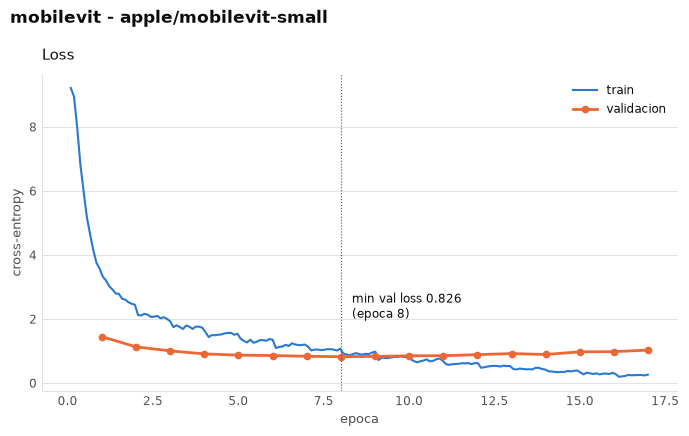

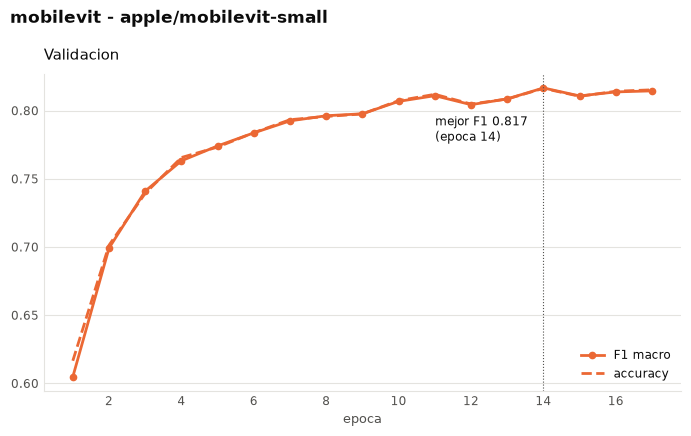

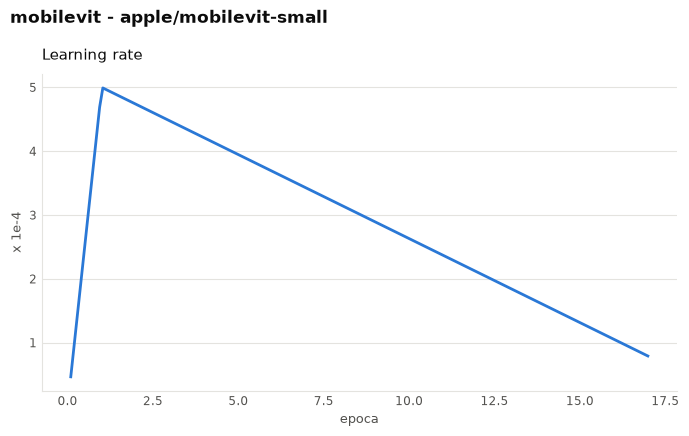

In [12]:
log_history = trainer.state.log_history
plots.history_table(log_history).to_csv(RESULTS_DIR / "training_history.csv", index=False)
rutas = plots.plot_training_curves(
    log_history,
    f"{MODEL_KEY} - {config.MODELS[MODEL_KEY]}",
    RESULTS_DIR,
    prefix=f"curvas-{MODEL_KEY}",
)


## 8. Guardar el mejor modelo

In [13]:
BEST_DIR = training.save_best_model(trainer, OUTPUT_DIR)


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 41.67it/s]

2026-09-26 04:56:00.329 | SUCCESS  | vit_for_101_food_app.modeling.training:save_best_model:243 - mejor modelo guardado en C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\models\mobilevit\full\best


## 8.1 Descargar el modelo a tu computadora

Comprime el mejor modelo y, en Colab, lo descarga al navegador. El `.zip` trae los pesos (`model.safetensors`) y la config, listos para `AutoModelForImageClassification.from_pretrained(carpeta_descomprimida)` (o para el CLI `python -m vit_for_101_food_app.modeling.predict`).

Si la descarga del navegador falla, con `USE_DRIVE = True` el modelo ya quedo en tu Drive (`OUTPUT_DIR/best`).

In [14]:
zip_path = training.zip_model(
    BEST_DIR,
    Path("/content") / f"{MODEL_KEY}-best" if IN_COLAB else OUTPUT_DIR / f"{MODEL_KEY}-best",
)
training.download_to_browser(zip_path)


2026-09-26 04:56:01.246 | SUCCESS  | vit_for_101_food_app.modeling.training:zip_model:251 - modelo comprimido en C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\models\mobilevit\full\mobilevit-best.zip
2026-09-26 04:56:01.247 | INFO     | vit_for_101_food_app.modeling.training:download_to_browser:262 - no es Colab: el archivo quedo en C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\models\mobilevit\full\mobilevit-best.zip


## 9. Evaluacion final sobre test

`test` se usa recien aca, una sola vez. Las predicciones se guardan **por imagen** (`predictions_test.csv`): con eso se recalcula cualquier metrica y se compara contra los otros modelos sin reentrenar.

In [15]:
test_preds, test_metrics, elapsed_test = evaluation.evaluate_test(trainer, test_ds, id2label)
test_preds.to_csv(RESULTS_DIR / "predictions_test.csv", index=False)

print(f"tiempo test: {elapsed_test:.1f} s")
pd.Series(test_metrics)


tiempo test: 63.8 s


n                25250.000000
n_clases           101.000000
accuracy             0.860475
top5_accuracy        0.968792
f1_macro             0.860850
dtype: float64

## 10. Subset del benchmark por tercil de dificultad

La tabla que contesta la pregunta del proyecto. El subset es **el mismo archivo para todos los modelos** y `load_benchmark_subset` verifica su `sha256` antes de usarlo.

In [16]:
subset = evaluation.load_benchmark_subset()
benchmark_tabla = evaluation.benchmark_metrics(test_preds, subset)
benchmark_tabla.to_csv(RESULTS_DIR / "benchmark_por_tercil.csv")
benchmark_tabla


,n,n_clases,accuracy,top5_accuracy,f1_macro
grupo,,,,,
subset,2525,101,0.861782,0.969505,0.862392
facil,850,34,0.928235,0.980000,0.949538
medio,825,33,0.875152,0.979394,0.909389
dificil,850,34,0.782353,0.949412,0.815592


## 11. Reporte por clase

In [17]:
report_df = evaluation.per_class_report(test_preds, id2label)
report_df.to_csv(RESULTS_DIR / "report_por_clase_test.csv")

print("10 clases con peor F1")
display(report_df.head(10))
print("10 clases con mejor F1")
display(report_df.tail(10))


10 clases con peor F1


,precision,recall,f1-score,support
steak,0.517751,0.700,0.595238,250.0
pork_chop,0.617241,0.716,0.662963,250.0
apple_pie,0.734597,0.620,0.672451,250.0
filet_mignon,0.697095,0.672,0.684318,250.0
bread_pudding,0.703557,0.712,0.707753,250.0
chocolate_mousse,0.677536,0.748,0.711027,250.0
foie_gras,0.720000,0.720,0.720000,250.0
ravioli,0.821429,0.644,0.721973,250.0
huevos_rancheros,0.801843,0.696,0.745182,250.0
chocolate_cake,0.798206,0.712,0.752643,250.0


10 clases con mejor F1


,precision,recall,f1-score,support
hot_and_sour_soup,0.936508,0.944,0.940239,250.0
lobster_roll_sandwich,0.962343,0.920,0.940695,250.0
miso_soup,0.937008,0.952,0.944444,250.0
spaghetti_bolognese,0.930233,0.960,0.944882,250.0
spaghetti_carbonara,0.927481,0.972,0.949219,250.0
seaweed_salad,0.963115,0.940,0.951417,250.0
oysters,0.959514,0.948,0.953722,250.0
deviled_eggs,0.948617,0.960,0.954274,250.0
macarons,0.948617,0.960,0.954274,250.0
edamame,0.988142,1.000,0.994036,250.0


## 12. Confusiones mas frecuentes

In [18]:
confusiones = evaluation.frequent_confusions(test_preds)
confusiones.to_csv(RESULTS_DIR / "confusiones_test.csv", index=False)
print("errores totales:", int((~test_preds["correct"]).sum()), "de", len(test_preds))
confusiones.head(15)


errores totales: 3523 de 25250


,class_dir,pred_class,n
0,filet_mignon,steak,50
1,steak,filet_mignon,35
2,chocolate_cake,chocolate_mousse,32
3,pork_chop,steak,31
4,prime_rib,steak,30
5,tuna_tartare,beef_tartare,26
6,ravioli,gnocchi,25
7,chocolate_mousse,chocolate_cake,19
8,apple_pie,bread_pudding,19
9,lobster_bisque,clam_chowder,18


## 13. Costo arquitectonico: parametros, FLOPs, tamanio y latencia

Se mide con `modeling/evaluation.py`, el mismo codigo para todos los modelos: esa es la condicion para comparar arquitecturas.

- **Tamanio de los pesos** por precision: fp32 (lo que se entrena) y las cotas fp16/int8, que es lo que ocuparia el modelo cuantizado al enviarlo a un dispositivo.
- **Latencia** con batch 1 (una foto por vez), mediana y p90 de 100 corridas, en GPU y CPU.
- **Medicion del lado del dispositivo**: el modelo cuantizado a int8 (dinamica sobre capas `Linear`) medido en CPU — tamanio real serializado y latencia. Es lo que sostiene el eje "recursos acotados" mas alla de FLOPs/params en la GPU de entrenamiento.

In [19]:
sample = test_ds[0]["pixel_values"].unsqueeze(0)
costo, latencia = evaluation.architectural_cost(model, sample, trainer.args.device)

print(pd.Series(costo))

# Latencia fp32 en GPU (si hay) y CPU
lat_fp32 = {k: v for k, v in latencia.items() if k in ("gpu", "cpu") and v is not None}
display(pd.DataFrame(lat_fp32))

# Medicion del lado del dispositivo: modelo cuantizado a int8 medido en CPU
print("\nCPU int8 (cuantizado):")
print(pd.Series(latencia["cpu_int8"]))


W0926 04:57:05.346000 6244 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


params_m         5.002373
size_mb_fp32    19.082539
size_mb_fp16     9.541269
size_mb_int8     4.770635
gflops           4.000512
gmacs            2.000256
dtype: float64


,gpu,cpu
device,NVIDIA GeForce RTX 5060 Laptop GPU,cpu
batch_size,1,1
cpu_threads,1,1
n_runs,100,100
median_ms,9.7853,105.7017
p90_ms,12.27353,116.73284
mean_ms,10.253749,99.031105



CPU int8 (cuantizado):
soportado                            True
dtype                               qint8
capas_cuantizadas    nn.Linear (dinamica)
size_mb                         10.848126
median_ms                        74.52575
p90_ms                           93.60217
mean_ms                         76.080364
n_runs                                 50
dtype: object


## 14. Guardar metricas

In [20]:
metrics = benchmark.assemble_metrics(
    MODEL_KEY, recipe, trainer, elapsed_train, test_metrics, benchmark_tabla, costo, latencia
)
destino = benchmark.save_metrics(metrics, RESULTS_DIR)
print("guardado en", destino)
for p in sorted(RESULTS_DIR.iterdir()):
    print(" -", p.name)


guardado en C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\reports\results\mobilevit\metrics.json
 - benchmark_por_tercil.csv
 - confusiones_test.csv
 - curvas-mobilevit-loss.png
 - curvas-mobilevit-lr.png
 - curvas-mobilevit-validacion.png
 - metrics.json
 - predictions_test.csv
 - report_por_clase_test.csv
 - training_history.csv


## Resumen

- Todo el codigo de modelo/entrenamiento vive en `vit_for_101_food_app/modeling/` (`training.py`, `evaluation.py`, `benchmark.py`); esta notebook solo orquesta.
- `train` para entrenar, `val` para early stopping y seleccion de checkpoint, `test` una sola vez.
- La metrica que contesta la pregunta del proyecto es la del **subset por tercil** (sección 10).
- El mejor modelo queda en `models/mobilevit/full/best/` y se descarga a tu compu (sección 8.1); **no** se versiona.

Con los `metrics.json` de cada modelo (mismo esquema para todos) se arma la tabla comparativa del benchmark sin reentrenar.

**En Colab** con `USE_DRIVE = True`, los resultados quedan en `ceia-vpc3/results/mobilevit/` de tu Drive: para versionarlos, copialos a `reports/results/mobilevit/` del checkout local.